In [1]:
from vislearnlabpy.embeddings.generate_embeddings import EmbeddingGenerator, EmbeddingConfig
from vislearnlabpy.embeddings.embedding_store import EmbeddingStore
from vislearnlabpy.embeddings.similarity_utils import csv_to_text_pairs, plot_rdm
import os

/Users/vislearnlab/miniconda3/envs/vllpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-08 19:02:16,953	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# running this on an M2 mac 
config = EmbeddingConfig(model_type="clip", device="mps", output_type="doc")
generator = EmbeddingGenerator(config=config)
PROJECT_PATH = os.getcwd()
input_csv = os.path.join(PROJECT_PATH, "data", "peekbank_stimuli.csv")
# path to the images
input_path = os.path.join(PROJECT_PATH, "data")

In [3]:
generator.generate_image_embeddings(output_path="embeddings", input_csv=input_csv, input_dir=input_path, batch_size=100, id_column="unique_pair", overwrite=True)

Calculating text embeddings: 100%|██████████| 270/270 [00:01<00:00, 139.75it/s]


In [4]:
image_embedding_store = EmbeddingStore.from_doc("embeddings/image_embeddings/clip_image_embeddings_doc.docs")
text_embedding_store = EmbeddingStore.from_doc("embeddings/text_embeddings/clip_text_embeddings_doc.docs")

/Users/vislearnlab/miniconda3/envs/vllpy/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [5]:
from vislearnlabpy.embeddings.utils import display_search_results
docs, scores = image_embedding_store.search_store(text_query="dog")
display_search_results(docs, scores)

In [6]:
import pandas as pd
def csv_to_path_pairs(path_pair_csv):
    df = pd.read_csv(path_pair_csv)
    cwd = input_path
    return [(os.path.join(cwd, img1), os.path.join(cwd, img2)) for img1, img2 in df[['image1', 'image2']].itertuples(index=False, name=None)]

In [7]:
image_df = image_embedding_store.retrieve_similarities(text_pairs=csv_to_path_pairs(input_csv), use_urls=True)
text_df = text_embedding_store.retrieve_similarities(text_pairs=csv_to_text_pairs(input_csv))

Skipping missing pair of dog and nan
Skipping missing pair of carrot and nan
Skipping missing pair of teddy bear and nan
Skipping missing pair of flower and nan
Skipping missing pair of ball and nan
Skipping missing pair of bicycle and nan
Skipping missing pair of car and nan
Skipping missing pair of apple and nan


In [8]:
multimodal_df = image_embedding_store.multimodal_prob(text_store = text_embedding_store, pairs=csv_to_path_pairs(input_csv), use_urls=True)
multimodal_df_logit10 = image_embedding_store.multimodal_prob(text_store = text_embedding_store, pairs=csv_to_path_pairs(input_csv), use_urls=True, logit=10)
multimodal_df_luce = image_embedding_store.multimodal_prob(text_store = text_embedding_store, pairs=csv_to_path_pairs(input_csv), use_urls=True, rule="luce")

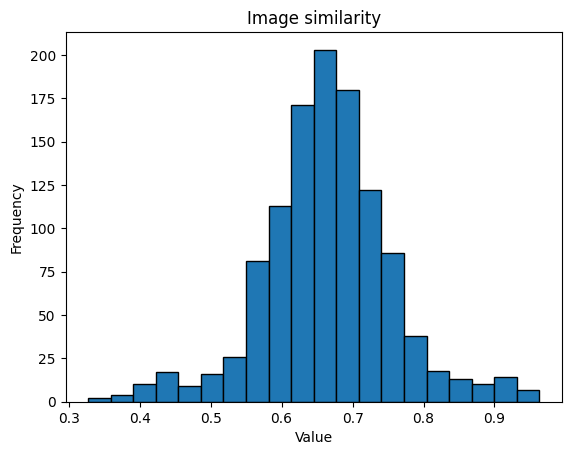

In [9]:
import matplotlib.pyplot as plt

plt.hist(image_df['cosine_similarity'], bins=20, edgecolor='black')
plt.title('Image similarity')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

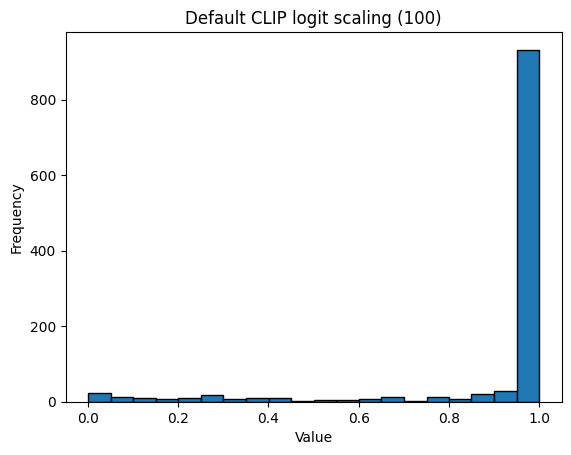

In [10]:
import matplotlib.pyplot as plt

plt.hist(multimodal_df['multimodal_prob'], bins=20, edgecolor='black')
plt.title('Default CLIP logit scaling (100)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

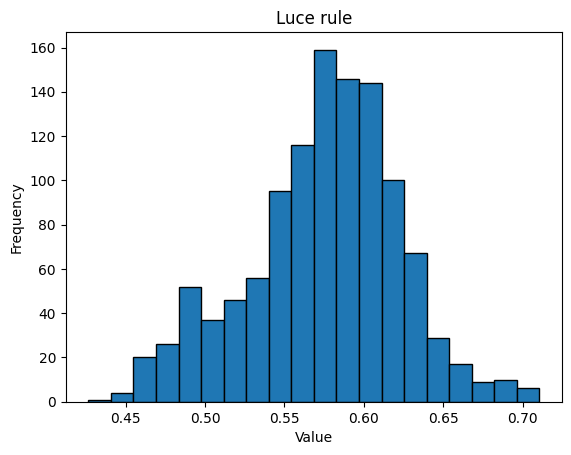

In [11]:
import matplotlib.pyplot as plt

plt.hist(multimodal_df_luce['multimodal_prob'], bins=20, edgecolor='black')
plt.title('Luce rule')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

all the skipped pairs are non-vanilla so ignoring for now.

Missing pairs being skipped above are from Frank 2015, which has empty descriptions for novel words.

Merging image and text similarity files.

In [13]:
odd_one_out_store = EmbeddingStore.from_doc("embeddings/odd_one_out_embeddings")

/Users/vislearnlab/miniconda3/envs/vllpy/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Some of the text pair values need to be updated to work with the limited set of THINGS labels.

In [14]:
replacements = {
    "kitty": "cat",
    "birdy": "bird",
    "doggy": "dog",
    "bicycle": "bike",
    "sofa": "couch",
    "keys": "key",
    "teddy": "teddy bear",
    "shoes": "shoe",
    "froggy": "frog",
    "bunny": "rabbit",
    "kittycat": "cat",
    "teddybear": "teddy bear",
    "ducky": "duck",
    "paci": "pacifier",
    "remote": "remote control",
    "fishy": "fish",
    "waterbottle": "water bottle",
    "blocks": "block"
}
reverse_replacements = {v: k for k, v in replacements.items()}

In [15]:
text_pairs=csv_to_text_pairs(input_csv)
def replace_value(x):
    return replacements.get(x, x)

text_pairs_replaced = [
    tuple(replace_value(v) for v in pair)
    for pair in text_pairs
]

In [16]:
ooo_df = odd_one_out_store.retrieve_similarities(text_pairs=text_pairs_replaced)

Skipping missing pair of lif and neem
Skipping missing pair of neem and lif
Skipping missing pair of water and bean
Skipping missing pair of bean and chile
Skipping missing pair of doorway and water
Skipping missing pair of chair and house
Skipping missing pair of house and pot
Skipping missing pair of chile and doorway
Skipping missing pair of novel and novel
Skipping missing pair of tempo and massager
Skipping missing pair of manju and fan
Skipping missing pair of tempo and massager
Skipping missing pair of manju and fan
Skipping missing pair of house and house
Skipping missing pair of tempo and manju
Skipping missing pair of tempo and manju
Skipping missing pair of fep and car
Skipping missing pair of wug and apple
Skipping missing pair of dax and cup
Skipping missing pair of kreeb and shoe
Skipping missing pair of toma and monkey
Skipping missing pair of pifo and frog
Skipping missing pair of dofa and train
Skipping missing pair of modi and shovel
Skipping missing pair of baba and 

In [17]:
from collections import defaultdict
import itertools

# Save THINGS-normalized names before expanding
ooo_df[["things_text1", "things_text2"]] = ooo_df[["text1", "text2"]]

# Build map: THINGS name → all original peekbank forms it was normalized from
norm_to_originals = defaultdict(set)
for orig, norm in replacements.items():
    norm_to_originals[norm].add(orig)

def all_forms(text):
    return {text} | norm_to_originals.get(text, set())

# Expand each row to cover every original-name combination so the merge in cell 24 works
expanded = []
for _, row in ooo_df.iterrows():
    for t1, t2 in itertools.product(all_forms(row["text1"]), all_forms(row["text2"])):
        r = row.copy()
        r["text1"], r["text2"] = t1, t2
        expanded.append(r)

ooo_df = pd.DataFrame(expanded)

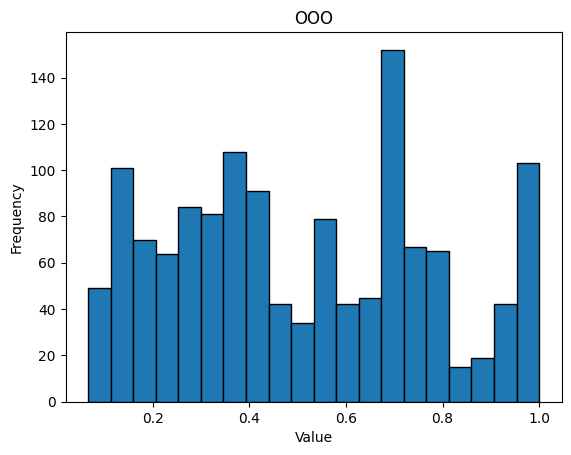

In [18]:
import matplotlib.pyplot as plt

plt.hist(ooo_df['cosine_similarity'], bins=20, edgecolor='black')
plt.title('OOO')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [19]:
ooo_df 

,cosine_similarity,text1,text2,things_text1,things_text2
0,0.387859,ball,shoe,ball,shoe
0,0.387859,ball,shoes,ball,shoe
1,0.387859,ball,shoe,ball,shoe
1,0.387859,ball,shoes,ball,shoe
2,0.387859,ball,shoe,ball,shoe
...,...,...,...,...,...
717,0.777445,car,bike,car,bike
718,0.907976,apple,orange,apple,orange
719,0.907976,orange,apple,orange,apple
720,0.907976,orange,apple,orange,apple


In [22]:
prefix = input_path.rstrip("/") + "/"

input_csv_df = pd.read_csv(input_csv).drop_duplicates(subset=["image1", "image2"])
input_csv_df["image1"] = prefix + input_csv_df["image1"]
input_csv_df["image2"] = prefix + input_csv_df["image2"]

image_df = image_df.rename(columns={"text1": "image1", "text2": "image2"}).drop_duplicates(subset=["image1", "image2"])
text_df = text_df.drop_duplicates(subset=["text1", "text2"])
multimodal_df_luce['multimodal_similarity'] = 1 - multimodal_df_luce["multimodal_prob"]
multimodal_df = multimodal_df_luce.drop_duplicates(subset=["id1", "id2"])
ooo_df = ooo_df.drop_duplicates(subset=["text1", "text2"])

full_df = (
    input_csv_df
    .merge(image_df, on=["image1", "image2"], how="left")
    .rename(columns={"cosine_similarity": "image_similarity"})
    .merge(text_df, on=["text1", "text2"], how="left")
    .rename(columns={"cosine_similarity": "text_similarity"})
    .merge(multimodal_df[["id1", "id2", "multimodal_similarity"]],
           left_on=["image1", "image2"], right_on=["id1", "id2"], how="left")
    .merge(ooo_df, on=["text1", "text2"], how="left")
    .rename(columns={"cosine_similarity": "ooo_similarity"})
    .assign(ooo_similarity=lambda x: x["ooo_similarity"].round(4))
    .drop(columns=["id1", "id2"])
)
full_df[["image1", "image2"]] = full_df[["image1", "image2"]].apply(lambda c: c.str.replace(prefix, "", regex=False))
full_df.to_csv("data/similarities_data.csv", index=False)

In [21]:
import numpy as np
plot_rdm("rdm", np.stack(image_embedding_store.EmbeddingList.embedding))